In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

import sys
sys.path.append('..')
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5*(x-mu)**2 / sigma**2)
    return y/np.max(y)

In [2]:
#data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = '../Camera_Calibrations/Ximea_Camera/'
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [3]:
image_size = 14
masks = M_F.get_masks(size_x=image_size, size_y=image_size)
R, G, B, wavelength = S_F.getpixelefficiency()

cameras = ['Camera_Normal', 'Camera_Sharp', 'Camera_Broad']

R_nonsharp = 0.95*gaussian_model(wavelength, 650, 500)
G_nonsharp = 0.95*gaussian_model(wavelength, 650, 500)
B_nonsharp = 0.95*gaussian_model(wavelength, 650, 500)

R_sharp = copy(R)
G_sharp = copy(G)
B_sharp = copy(B)
B_sharp[wavelength < 500] = 0.95
B_sharp[wavelength >= 500] = 0
G_sharp[(wavelength < 500) | (wavelength > 600)] = 0
G_sharp[(wavelength < 600) & (wavelength >= 500)] = 0.95
R_sharp[wavelength < 600] = 0
R_sharp[wavelength >= 600] = 0.95

wavelength = wavelength
pixel_QYs_normal = np.vstack([B, G, R])
pixel_QYs_broad = np.vstack([B_nonsharp, G_nonsharp, R_nonsharp])
pixel_QYs_sharp = np.vstack([B_sharp, G_sharp, R_sharp])

camera_parameters = {}

for camera in cameras:
    camera_parameters[camera] = {}
    camera_parameters[camera]["gain"] = np.full((image_size, image_size), np.median(gain))
    camera_parameters[camera]["variance"] = np.full((image_size, image_size), np.median(variance))
    camera_parameters[camera]["readnoise"] = np.full((image_size, image_size), np.median(readnoise))
    camera_parameters[camera]["offset"] = np.full((image_size, image_size), np.median(offset))
    camera_parameters[camera]["rqe"] = np.full((image_size, image_size), np.median(rqe))
    camera_parameters[camera]["pixel_order"] = ['B', 'G', 'R']
    camera_parameters[camera]["pixel_order_indices"] = [0, 1, 2]
    camera_parameters[camera]["masks"] = masks
    if camera == 'Camera_Normal':
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_normal
    elif camera == 'Camera_Sharp':
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_sharp        
    else:
        camera_parameters[camera]["pixel_QYs"] = pixel_QYs_broad                

In [4]:
dyes = ['CF488A', 'ATTO 565', 'ATTO 647N', 'Cy3B']
photons_per_dye = np.array([3879, 11600, 18448, 23195])
n_bootstrap = 20000
background_photons = 40
pixel_size = 69
NA = 1.49

In [5]:
import types
smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma" :  1.5}
smoothing_function.extent =  1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [6]:
notch_filter = 'semrock-nf03-405-488-561-635e'
dichroic_mirror = 'semrock-di03-r405-488-561-635-t1-25x36'
nilered_filter = 'semrock-ff01-650-200-25'
shortpass_filter = 'semrock-bsp01-785r'
filters = [dichroic_mirror, shortpass_filter, notch_filter]

In [7]:
save_folder = r'/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Data/Simulation/20250730_3Cameras_Figure1'
if not os.path.isdir(save_folder):
    os.makedirs(save_folder)

In [8]:
for i, dye in enumerate(dyes):
    for camera in cameras:
        print("Analysing dye {}".format(dye), end="\r",flush=True,)        
        MSF.test_fit_method(
                                dye,
                                filters,
                                wavelength,
                                camera_parameters[camera],
                                save_folder,
                                np.array([photons_per_dye[i]]),
                                smoothing_function=smoothing_function,
                                starting_flag="3cameras_"+str(camera)+'_',
                                n_bootstrap=n_bootstrap,
                                background_photons=background_photons,
                                NA=NA,
                                pixel_size=pixel_size,
                                cpu_fraction=1,
                                save_raw_results=True,
                                subtractx0y0=True,
                                saverawimages=True
                            )

LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 258.36task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 258.22task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 255.12task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 259.63task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 262.19task/s]


...

LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 247.32task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:07<00:00, 250.81task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 268.18task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 262.03task/s]


LM fitting: 100%|████████████████████████| 1800/1800 [00:06<00:00, 264.36task/s]


In [9]:
all_files = np.sort(os.listdir(save_folder))
Overall_XR = xr.DataArray(data=np.zeros([n_bootstrap, len(dyes), 7, 3]),
                          coords=[np.arange(n_bootstrap)+1, dyes, ['xc', 'yc', 'B', 'G', 'R', 'chi_squared', 'photons'], ['Camera_Normal', 'Camera_Sharp', 'Camera_Broad']],
                         dims=['Bootstrap_Repeat', 'Dye', 'Parameter', 'Camera'])

Overall_pd = {}
for i, dye in enumerate(dyes):
    for q, camera in enumerate(cameras):
        files = np.sort([os.path.join(save_folder, x) for x in all_files if dye in x and 'rawresults' in x and '#' not in x and camera in x])
        for j, file in enumerate(files):
            data = pl.read_csv(file)
            if i + q == 0:
                Overall_pd['dye'] = np.full_like(data['xc'].to_numpy(), dye, dtype='object')
                Overall_pd['camera'] = np.full_like(data['xc'].to_numpy(), camera, dtype='object')
            else:
                Overall_pd['dye'] = np.hstack([Overall_pd['dye'], np.full_like(data['xc'].to_numpy(), dye, dtype='object')])
                Overall_pd['camera'] = np.hstack([Overall_pd['camera'], np.full_like(data['xc'].to_numpy(), camera, dtype='object')])
            for k, parameter in enumerate(np.array(['xc', 'yc', 'A_B', 'A_G', 'A_R', 'chi_sqr', 'photons'])):
                Overall_XR[:, i, k, q] = data[parameter].to_numpy()
                if i + q + j == 0:
                    Overall_pd[parameter] = data[parameter].to_numpy()
                else:
                    Overall_pd[parameter] = np.hstack([Overall_pd[parameter], data[parameter].to_numpy()])

Overall_XR.to_netcdf(os.path.join(save_folder, 'Simulated_3camera_database.nc'))
pandas_df = pd.DataFrame(Overall_pd)
pandas_df.to_csv(os.path.join(save_folder, 'Simulated_3camera_database_pandas.csv'))

In [ ]:
all_files = np.sort(os.listdir(save_folder))
all_files = np.sort([os.path.join(save_folder, x) for x in all_files if 'rawresults' in x])
for file in all_files:
    os.remove(file)

In [ ]:
camera_sharp = pandas_df[pandas_df['camera'] == 'Camera_Sharp']
camera_broad = pandas_df[pandas_df['camera'] == 'Camera_Broad']
camera_bayer = pandas_df[pandas_df['camera'] == 'Camera_Normal']

fig, axs = plotter.two_column_plot(ncolumns=3, nrows=3, widthratio=[1,1,1], height=6, heightratio=[1,1,1])

cs = ["#8975ca",
      "#71a659",
      "#cb5582",
      "#c5783e"]

axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=B_sharp, color='darkblue')
axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=G_sharp, color='darkgreen')
axs[0, 0] = plotter.line_plot(axs=axs[0, 0], x=wavelength, y=R_sharp, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=B, color='darkblue')
axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=G, color='darkgreen')
axs[0, 1] = plotter.line_plot(axs=axs[0, 1], x=wavelength, y=R, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=B_nonsharp, color='darkblue')
axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=G_nonsharp, color='darkgreen')
axs[0, 2] = plotter.line_plot(axs=axs[0, 2], x=wavelength, y=R_nonsharp, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[1, 0] = sns.kdeplot(camera_sharp, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,0], palette=cs, linewidths=0.1, common_norm=False)
axs[1, 1] = sns.kdeplot(camera_bayer, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,1], palette=cs, linewidths=0.1, common_norm=False)
axs[1, 2] = sns.kdeplot(camera_broad, x="A_G", y="A_R", hue="dye", levels=20, ax=axs[1,2], palette=cs, linewidths=0.1, common_norm=False)

for i in np.arange(3):
    axs[0, i].set_ylim([0, 1])
    axs[0, i].set_xlim([400, 800])

for i in np.arange(3):
    axs[1, i].set_ylim([-0.05, 1.05])
    axs[1, i].set_xlim([-0.05, 1.05])
    axs[1, i].set_ylabel('R')
    axs[1, i].set_xlabel('G')

axs[2, 0] = plotter.histogram_plot(axs=axs[2,0], 
                                   data=np.abs(camera_sharp['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_sharp['xc'])*69, 'fd'),
                                  xaxislabel='localisaiton RMSE/nm')
axs[2, 1] = plotter.histogram_plot(axs=axs[2,1], 
                                   data=np.abs(camera_bayer['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_bayer['xc'])*69, 'fd'),
                                  xaxislabel='localisation RMSE/nm')
axs[2, 2] = plotter.histogram_plot(axs=axs[2,2], 
                                   data=np.abs(camera_broad['xc'])*69, bins=np.histogram_bin_edges(np.abs(camera_broad['xc'])*69, 'fd'),
                                  xaxislabel='localisation RMSE/nm')

for i in np.arange(3):
    axs[2, i].set_xlim([0, 140])
    axs[2, i].set_yscale('log')
    axs[2, i].set_ylim([1e-5, 1])


folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1'
plt.savefig(os.path.join(folder, 'Exemplar_Camera_QEs.svg'), dpi=600, format='svg')

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1,1,1], height=1.6, width=1.75*3)

cs = ["#8975ca",
      "#71a659",
      "#cb5582",
      "#c5783e"]

axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=B_sharp, color='blue')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=G_sharp, color='green')
axs[1] = plotter.line_plot(axs=axs[1], x=wavelength, y=R_sharp, color='red', yaxislabel='QE', xaxislabel='wavelength')

axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=B, color='darkblue')
axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=G, color='darkgreen')
axs[2] = plotter.line_plot(axs=axs[2], x=wavelength, y=R, color='darkred', yaxislabel='QE', xaxislabel='wavelength')

axs[0] = plotter.line_plot(axs=axs[0], x=wavelength, y=B_nonsharp, color='black', yaxislabel='QE', xaxislabel='wavelength')

for i in np.arange(3):
    axs[i].set_ylim([0, 1])
    axs[i].set_xlim([400, 800])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1'
plt.savefig(os.path.join(folder, 'Exemplar_Camera_justQEs.svg'), dpi=600, format='svg')

In [14]:
broad_camera_files = os.listdir(save_folder)
broad_camera_files = np.sort([os.path.join(save_folder, x) for x in broad_camera_files if 'Camera_Broad' in x and 'ATTO 565' in x])
sharp_camera_files = os.listdir(save_folder)
sharp_camera_files = np.sort([os.path.join(save_folder, x) for x in sharp_camera_files if 'Camera_Sharp' in x and 'ATTO 565' in x])
normal_camera_files = os.listdir(save_folder)
normal_camera_files = np.sort([os.path.join(save_folder, x) for x in normal_camera_files if 'Camera_Normal' in x and 'ATTO 565' in x])

In [31]:
raw_results_broad = pd.read_csv([x for x in broad_camera_files if '_rawresults.csv' in x][0], index_col=0)
raw_results_sharp = pd.read_csv([x for x in sharp_camera_files if '_rawresults.csv' in x][0], index_col=0)
raw_results_normal = pd.read_csv([x for x in normal_camera_files if '_rawresults.csv' in x][0], index_col=0)

In [57]:
GT_pos_broad = pd.read_csv([x for x in broad_camera_files if '_groundtruthpositions.csv' in x][0])
GT_pos_sharp = pd.read_csv([x for x in sharp_camera_files if '_groundtruthpositions.csv' in x][0])
GT_pos_normal = pd.read_csv([x for x in normal_camera_files if '_groundtruthpositions.csv' in x][0])

In [46]:
tiff_broad = IO.read_tiff([x for x in broad_camera_files if '.tiff' in x][0])
tiff_sharp = IO.read_tiff([x for x in sharp_camera_files if '.tiff' in x][0])
tiff_normal = IO.read_tiff([x for x in normal_camera_files if '.tiff' in x][0])

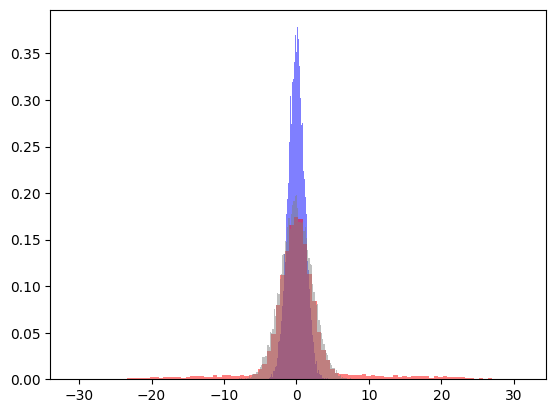

In [47]:
plt.hist(raw_results_broad['xc']*69, 100, alpha=0.5, density=True, color='blue');
plt.hist(raw_results_sharp['xc']*69, 100, alpha=0.5, density=True, color='red');
plt.hist(raw_results_normal['xc']*69, 100, alpha=0.5, density=True, color='gray');
plt.show()

In [84]:
broad_index = np.argmin(np.abs(raw_results_broad['xc']*69 - 0.9))
normal_index = np.argmin(np.abs(raw_results_normal['xc']*69 - 1))
sharp_index = np.argmin(np.abs(raw_results_sharp['xc']*69 - 30))

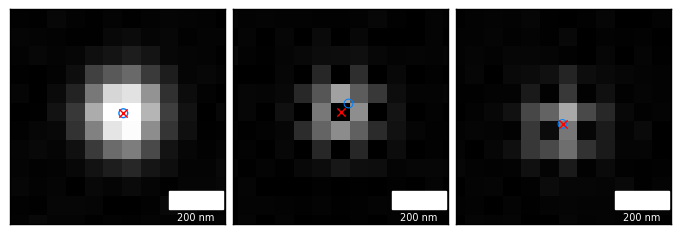

In [146]:
fig, axs = plotter.two_column_plot(ncolumns=3, widthratio=[1,1,1])

vmin = np.percentile(tiff_broad[broad_index, :, :], 1)
vmax = np.percentile(tiff_broad[broad_index, :, :], 99)

axs[0] = plotter.image_plot(axs[0], tiff_broad[broad_index, :, :], vmax=vmax, vmin=vmin, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
axs[0].scatter(raw_results_broad['yc'][broad_index]+GT_pos_broad['y0'][broad_index]/69, 
               raw_results_broad['xc'][broad_index]+GT_pos_broad['x0'][broad_index]/69, facecolors="None", s=40, lw=1, edgecolors='#0080ff')
axs[0].scatter(GT_pos_broad['y0'][broad_index]/69, GT_pos_broad['x0'][broad_index]/69, marker='x', lw=1, facecolors="red")


axs[1] = plotter.image_plot(axs[1], tiff_sharp[sharp_index, :, :], vmax=vmax, vmin=vmin, cbar='off', scalebarsize=200, scalebarlabel='200 nm')
axs[1].scatter(raw_results_sharp['yc'][sharp_index]+GT_pos_sharp['y0'][sharp_index]/69, 
               raw_results_sharp['xc'][sharp_index]+GT_pos_sharp['x0'][sharp_index]/69, facecolors="None", s=40, lw=0.75, edgecolors='#0080ff')
axs[1].scatter(GT_pos_sharp['y0'][sharp_index]/69, GT_pos_sharp['x0'][sharp_index]/69, marker='x', lw=1, facecolors="red")

axs[2] = plotter.image_plot(axs[2], tiff_normal[normal_index, :, :], cbar='off', vmax=vmax, vmin=vmin, scalebarsize=200, scalebarlabel='200 nm')
axs[2].scatter(raw_results_normal['yc'][normal_index]+GT_pos_normal['y0'][normal_index]/69, 
               raw_results_normal['xc'][normal_index]+GT_pos_normal['x0'][normal_index]/69, facecolors="None", s=40, lw=0.75, edgecolors='#0080ff')
axs[2].scatter(GT_pos_normal['y0'][normal_index]/69, GT_pos_normal['x0'][normal_index]/69, marker='x', lw=1, facecolors="red")

axs[0].set_ylim([2, 13.5])
axs[0].set_xlim([0.5, 12])

axs[1].set_ylim([0, 11.5])
axs[1].set_xlim([0.25, 11.75])

axs[2].set_ylim([1, 12.5])
axs[2].set_xlim([1, 12.5])

folder = '/home/jbeckwith/Documents/pCloud/Chemistry/Lee/Papers/Multicolour/Figure1'
plt.savefig(os.path.join(folder, 'Exemplar_Fits.svg'), dpi=600, format='svg')

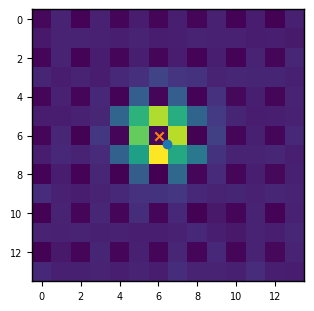

In [89]:
plt.imshow(tiff_sharp[sharp_index, :, :])
plt.scatter(raw_results_sharp['yc'][sharp_index]+GT_pos_sharp['y0'][sharp_index]/69, raw_results_sharp['xc'][sharp_index]+GT_pos_sharp['x0'][sharp_index]/69)
plt.scatter(GT_pos_sharp['y0'][sharp_index]/69, GT_pos_sharp['x0'][sharp_index]/69, marker='x')

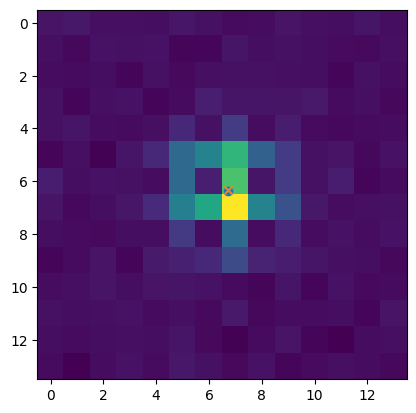

In [86]:
plt.imshow(tiff_normal[normal_index, :, :])
plt.scatter(raw_results_normal['yc'][normal_index]+GT_pos_normal['y0'][normal_index]/69, raw_results_normal['xc'][normal_index]+GT_pos_normal['x0'][normal_index]/69)
plt.scatter(GT_pos_normal['y0'][normal_index]/69, GT_pos_normal['x0'][normal_index]/69, marker='x')


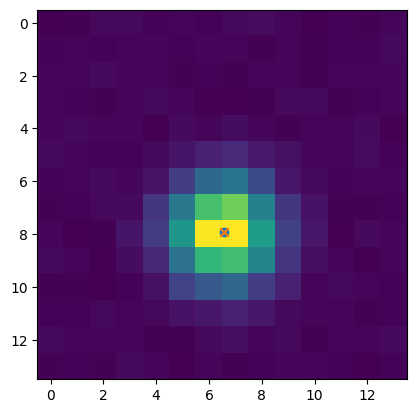

In [87]:
plt.imshow(tiff_broad[broad_index, :, :])
plt.scatter(raw_results_broad['yc'][broad_index]+GT_pos_broad['y0'][broad_index]/69, raw_results_broad['xc'][broad_index]+GT_pos_broad['x0'][broad_index]/69)
plt.scatter(GT_pos_broad['y0'][broad_index]/69, GT_pos_broad['x0'][broad_index]/69, marker='x')
